In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('vgsales.csv')

In [4]:
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [6]:
df.shape


(16598, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [18]:
print(f'До чистки: {len(df)} строк')

До чистки: 16598 строк


In [21]:
# убираем строки без года и жанра
df = df.dropna(subset=['Year', 'Genre'])

# убираем явно неверные годы
df = df[df['Year'] <= 2016]

print(f'После чистки: {len(df)} строк')
df.to_csv('vgsales_clean.csv', index=False)
print('Сохранено!')

После чистки: 16323 строк
Сохранено!


In [26]:
import sqlite3


conn = sqlite3.connect('games.db')
df.to_sql('games', conn, if_exists='replace', index=False)


def sql(query):
    return pd.read_sql(query, conn)

# топ-10 самых продаваемых игр в мире
sql("""
    SELECT Name, Global_Sales
    FROM games
    ORDER BY Global_Sales DESC
    LIMIT 10
""")

,Name,Global_Sales
0,Wii Sports,82.74
1,Super Mario Bros.,40.24
2,Mario Kart Wii,35.82
3,Wii Sports Resort,33.00
4,Pokemon Red/Pokemon Blue,31.37
5,Tetris,30.26
6,New Super Mario Bros.,30.01
7,Wii Play,29.02
8,New Super Mario Bros. Wii,28.62
9,Duck Hunt,28.31


In [27]:
sql("""
    SELECT Genre,
           ROUND(SUM(Global_Sales), 1) AS total_sales,
           COUNT(*) AS games_count
    FROM games
    GROUP BY Genre
    ORDER BY total_sales DESC
""")

,Genre,total_sales,games_count
0,Action,1722.9,3252
1,Sports,1309.2,2304
2,Shooter,1026.2,1282
3,Role-Playing,923.8,1469
4,Platform,829.1,876
5,Misc,797.6,1710
6,Racing,726.8,1226
7,Fighting,444.1,836
8,Simulation,389.9,850
9,Puzzle,242.2,571


In [28]:
sql("""
    SELECT
        ROUND(SUM(NA_Sales), 1) AS северная_америка,
        ROUND(SUM(EU_Sales), 1) AS европа,
        ROUND(SUM(JP_Sales), 1) AS япония
    FROM games
""")

,северная_америка,европа,япония
0,4333.2,2409.1,1284.3


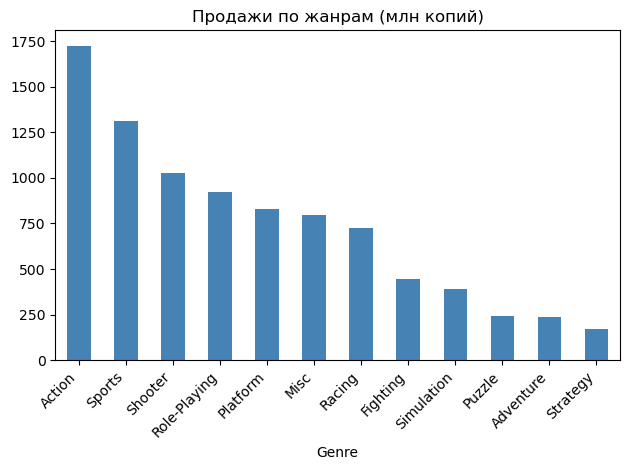

In [30]:
import matplotlib.pyplot as plt

# --- график 1: продажи по жанрам ---
genre_sales = sql("""
    SELECT Genre, SUM(Global_Sales) AS sales
    FROM games GROUP BY Genre
    ORDER BY sales DESC
""")

genre_sales.plot(kind='bar', x='Genre', y='sales',
                 color='steelblue', legend=False)
plt.title('Продажи по жанрам (млн копий)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

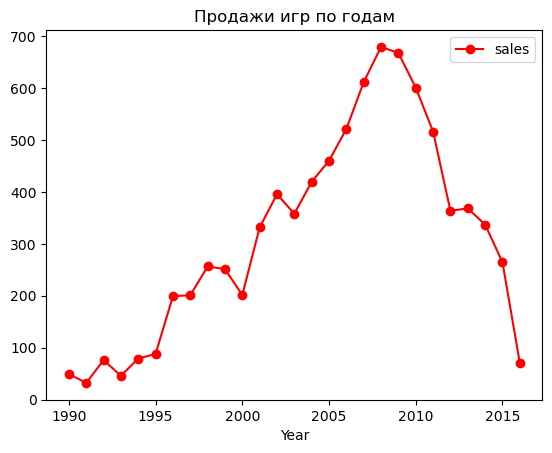

In [32]:
year_sales = sql("""
    SELECT Year, SUM(Global_Sales) AS sales
    FROM games
    WHERE Year >= 1990
    GROUP BY Year ORDER BY Year
""")

year_sales.plot(kind='line', x='Year', y='sales',
                marker='o', color='red')
plt.title('Продажи игр по годам')
plt.show()